# Smart Outcome Predictor — Ensemble Learning Project
**Course:** Supervised Learning | **Duration:** 6 Hours | **Role:** Machine Learning Engineer

This notebook implements a complete ensemble-based ML system to:
- **Classification Task:** Predict whether a student will *successfully complete* an online course (`completion_status`)
- **Regression Task:** Predict the *final performance score* of a student (`final_score`)

We cover Bagging, Boosting (AdaBoost, Gradient Boosting, LightGBM, XGBoost), Voting, and Stacking ensembles, and compare them all.


---
## 🧠 Part A: Conceptual Foundation (Theory)

**1. What are Ensemble Learning Methods and why are they effective?**

Ensemble learning combines predictions from multiple individual models (learners) instead of relying on a single model. They are effective because:
- Different models make different errors; combining them averages out individual mistakes.
- They reduce **variance** (by averaging, as in bagging), reduce **bias** (by sequential correction, as in boosting), and improve **generalization** to unseen data.
- A diverse "committee" of models is statistically less likely to make the same mistake than any single model.

**2. Explain the difference between Bagging, Boosting, and Voting.**

| Method | Idea | Models trained | Goal |
|---|---|---|---|
| **Bagging** | Train the *same* algorithm on different bootstrap (random with replacement) samples of data, then average/vote the results | In parallel, independent of each other | Reduce variance, increase stability |
| **Boosting** | Train models *sequentially*, each new model focusing more on the samples the previous models got wrong | Sequential, dependent on previous model's errors | Reduce bias, improve accuracy |
| **Voting** | Train several *different* algorithms (e.g. Logistic Regression, Decision Tree, KNN) on the *same* data, then combine their predictions by majority vote (hard) or averaged probability (soft) | In parallel, independent, usually different algorithm types | Combine strengths of diverse models |

**3. What is the Bias–Variance Trade-off, and how do ensemble methods address it?**

- **Bias** is the error from overly simplistic assumptions (underfitting).
- **Variance** is the error from being overly sensitive to the training data (overfitting).
- Reducing one tends to increase the other for a single model. Ensembles address this trade-off:
  - **Bagging** reduces variance by averaging many high-variance, low-bias models (e.g. deep decision trees) without increasing bias much.
  - **Boosting** reduces bias by sequentially combining many high-bias, low-variance weak learners (e.g. shallow trees/stumps) into a strong learner, while keeping variance controlled through learning rate and regularization.

**4. Explain Voting Classifier and Stacking Ensemble.**

- **Voting Classifier:** Combines predictions from several different base classifiers.
  - *Hard voting*: each model casts one vote for a class; the majority class wins.
  - *Soft voting*: each model outputs class probabilities; the probabilities are averaged and the class with the highest average probability wins. Soft voting usually performs better when base models give well-calibrated probabilities.
- **Stacking Ensemble:** Trains several diverse "base/level-0" models, then trains a separate **meta-learner** ("level-1" model) whose input features are the *predictions* of the base models. The meta-learner learns how to best combine the base models' outputs, often outperforming simple voting because it learns optimal weighting rather than assuming equal contribution.

**5. Compare AdaBoost, Gradient Boosting, LightGBM, and XGBoost conceptually.**

| Algorithm | Core Idea | Key Characteristic |
|---|---|---|
| **AdaBoost** | Re-weights misclassified samples after each weak learner (usually a decision stump) so the next learner focuses on hard cases | Simple, sensitive to noisy data/outliers since it keeps up-weighting hard points |
| **Gradient Boosting** | Each new tree is fit on the **residual errors (gradient of the loss function)** of the combined previous trees | More flexible loss functions; generally more accurate but slower to train |
| **LightGBM** | A fast, histogram-based implementation of gradient boosting that grows trees **leaf-wise** (best-first) rather than level-wise | Very fast and memory-efficient on large datasets; great for tabular data with many rows |
| **XGBoost** | Optimized, regularized gradient boosting with second-order gradient information and built-in handling of missing values | Highly accurate, robust, widely used in competitions; slightly slower than LightGBM but very tunable |

All four are boosting algorithms (sequential error correction), but they differ in how they re-weight samples/residuals, how they grow trees, and their speed/regularization trade-offs.


---
## 🧪 Part B: Dataset Understanding & Preparation


In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import StackingClassifier, StackingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import BaggingClassifier, BaggingRegressor
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, mean_absolute_error, mean_squared_error, r2_score)
from sklearn.ensemble import AdaBoostClassifier, AdaBoostRegressor
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
import time
from lightgbm import LGBMClassifier, LGBMRegressor
from sklearn.ensemble import VotingClassifier, VotingRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

pd.set_option('display.max_columns', None)

df = pd.read_csv('Smart_Outcome_Predictor_Dataset.csv')
print("Shape:", df.shape)
df.head()


Shape: (5200, 19)


,student_id,age,country_region,device_type,education_background,course_level,course_category,course_start_date,week_of_year,sessions,time_spent_hours,videos_watched,quiz_attempts,assignments_submitted,forum_posts,avg_quiz_score,attendance_rate,completion_status,final_score
0,700001,32,Europe,Laptop,Undergrad,Intermediate,Business,2024-03-18,12,1,7.6,1,6,1,1,53.3,0.655,0,49.8
1,700002,17,Europe,Laptop,Undergrad,Intermediate,Programming,2024-08-22,34,16,27.2,6,4,7,1,51.5,1.000,1,84.0
2,700003,25,Europe,Mobile,Graduate,Advanced,Programming,2024-09-28,39,6,7.1,16,2,2,0,62.2,0.810,0,62.5
3,700004,26,Asia,Mobile,Undergrad,Beginner,Design,2024-03-09,10,34,22.1,57,9,6,0,59.3,0.875,1,89.5
4,700005,26,Asia,Tablet,WorkingPro,Advanced,Business,2024-03-21,12,22,32.3,41,9,2,0,65.1,0.814,0,67.4


In [2]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5200 entries, 0 to 5199
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             5200 non-null   int64  
 1   age                    5200 non-null   int64  
 2   country_region         5200 non-null   object 
 3   device_type            5200 non-null   object 
 4   education_background   5200 non-null   object 
 5   course_level           5200 non-null   object 
 6   course_category        5200 non-null   object 
 7   course_start_date      5200 non-null   object 
 8   week_of_year           5200 non-null   int64  
 9   sessions               5200 non-null   int64  
 10  time_spent_hours       5088 non-null   float64
 11  videos_watched         5200 non-null   int64  
 12  quiz_attempts          5200 non-null   int64  
 13  assignments_submitted  5200 non-null   int64  
 14  forum_posts            5200 non-null   int64  
 15  avg_

In [3]:
df.describe()


,student_id,age,week_of_year,sessions,time_spent_hours,videos_watched,quiz_attempts,assignments_submitted,forum_posts,avg_quiz_score,attendance_rate,completion_status,final_score
count,5200.000000,5200.000000,5200.000000,5200.000000,5088.000000,5200.000000,5200.000000,5200.000000,5200.000000,5119.000000,5120.000000,5200.000000,5200.000000
mean,702600.500000,24.339615,26.621538,19.121923,18.216156,25.852885,6.995769,3.835769,1.585577,66.842626,0.847189,0.375385,74.821615
std,1501.255031,5.578864,15.007731,10.726708,10.734114,17.720493,2.568017,1.951802,1.270640,13.813992,0.113545,0.484269,13.531829
min,700001.000000,16.000000,1.000000,1.000000,0.600000,0.000000,0.000000,0.000000,0.000000,0.000000,0.313000,0.000000,35.200000
25%,701300.750000,20.000000,14.000000,11.000000,10.300000,13.000000,5.000000,2.000000,1.000000,57.500000,0.768750,0.000000,64.700000
50%,702600.500000,24.000000,27.000000,17.000000,16.100000,23.000000,7.000000,4.000000,1.000000,66.900000,0.855000,0.000000,74.100000
75%,703900.250000,28.000000,40.000000,25.000000,23.800000,35.000000,9.000000,5.000000,2.000000,76.200000,0.942000,1.000000,84.900000
max,705200.000000,45.000000,52.000000,94.000000,76.800000,158.000000,20.000000,12.000000,8.000000,100.000000,1.000000,1.000000,100.000000


In [4]:
# Check missing values
df.isnull().sum()


student_id                 0
age                        0
country_region             0
device_type                0
education_background       0
course_level               0
course_category            0
course_start_date          0
week_of_year               0
sessions                   0
time_spent_hours         112
videos_watched             0
quiz_attempts              0
assignments_submitted      0
forum_posts                0
avg_quiz_score            81
attendance_rate           80
completion_status          0
final_score                0
dtype: int64

**Task 6 — Identify features and target variables for both tasks.**

- **Classification target:** `completion_status` (0 = Not Completed, 1 = Completed)
- **Regression target:** `final_score` (0–100)
- **Features (common to both tasks):** all remaining columns except `student_id` (identifier, not predictive), and except the *other* target variable (to avoid data leakage — e.g. `final_score` should not be used as a feature when predicting `completion_status`, and vice versa).
- **Categorical features:** `country_region`, `device_type`, `education_background`, `course_level`, `course_category`
- **Numeric features:** `age`, `week_of_year`, `sessions`, `time_spent_hours`, `videos_watched`, `quiz_attempts`, `assignments_submitted`, `forum_posts`, `avg_quiz_score`, `attendance_rate`
- `course_start_date` is dropped/converted (date string, not directly usable by most models without feature engineering).


In [5]:
drop_cols = ['student_id', 'course_start_date']

categorical_cols = ['country_region', 'device_type', 'education_background',
                     'course_level', 'course_category']
numeric_cols = ['age', 'week_of_year', 'sessions', 'time_spent_hours',
                'videos_watched', 'quiz_attempts', 'assignments_submitted',
                'forum_posts', 'avg_quiz_score', 'attendance_rate']

target_clf = 'completion_status'
target_reg = 'final_score'

print("Categorical features:", categorical_cols)
print("Numeric features:", numeric_cols)
print("\nClassification target distribution:")
print(df[target_clf].value_counts(normalize=True))
print("\nRegression target summary:")
print(df[target_reg].describe())


Categorical features: ['country_region', 'device_type', 'education_background', 'course_level', 'course_category']
Numeric features: ['age', 'week_of_year', 'sessions', 'time_spent_hours', 'videos_watched', 'quiz_attempts', 'assignments_submitted', 'forum_posts', 'avg_quiz_score', 'attendance_rate']

Classification target distribution:
completion_status
0    0.624615
1    0.375385
Name: proportion, dtype: float64

Regression target summary:
count    5200.000000
mean       74.821615
std        13.531829
min        35.200000
25%        64.700000
50%        74.100000
75%        84.900000
max       100.000000
Name: final_score, dtype: float64


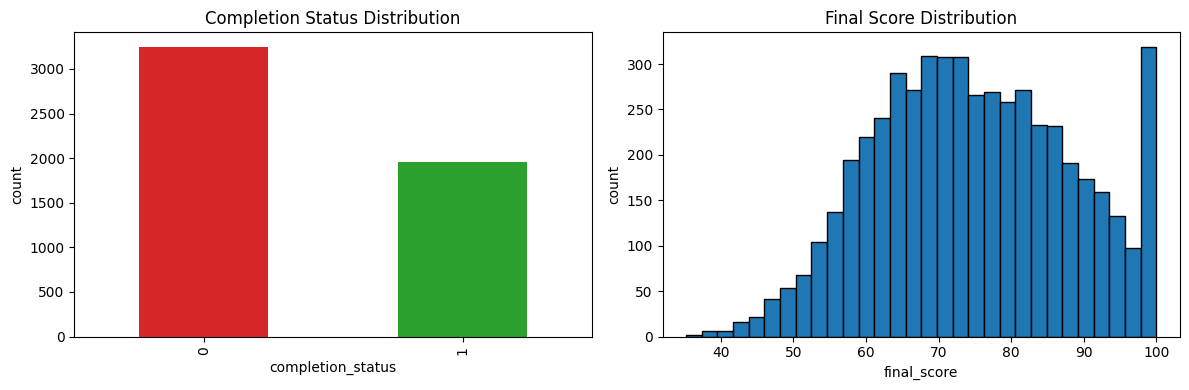

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df[target_clf].value_counts().plot(kind='bar', ax=axes[0], color=['#d62728', '#2ca02c'])
axes[0].set_title('Completion Status Distribution')
axes[0].set_xlabel('completion_status'); axes[0].set_ylabel('count')

axes[1].hist(df[target_reg], bins=30, color='#1f77b4', edgecolor='black')
axes[1].set_title('Final Score Distribution')
axes[1].set_xlabel('final_score'); axes[1].set_ylabel('count')
plt.tight_layout()
plt.show()


**Interpretation:** The classification target is reasonably balanced between completed/not-completed students, and the regression target (`final_score`) is roughly continuous across the 0–100 range, suitable for regression modeling without needing extra resampling.

**Task 7 & 8 — Train-test split and preprocessing (scaling/encoding).**

We build a single **preprocessing pipeline** using `ColumnTransformer`:
- One-Hot Encoding for categorical columns
- Standard Scaling for numeric columns

This pipeline is reused identically for both the classification and regression tasks so results are comparable.


In [ ]:
feature_cols = categorical_cols + numeric_cols
numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipe, numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

X = df[feature_cols]
y_clf = df[target_clf]
y_reg = df[target_reg]

# Classification split (stratified to preserve class balance)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

# Regression split
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_reg, test_size=0.2, random_state=42)

print("Classification -> train:", X_train_c.shape, "test:", X_test_c.shape)
print("Regression     -> train:", X_train_r.shape, "test:", X_test_r.shape)


Classification -> train: (4160, 15) test: (1040, 15)
Regression     -> train: (4160, 15) test: (1040, 15)


---
## 📦 Part C: Bagging (Bootstrap Aggregating)

**Task 9–11:** Implement Bagging Classifier & Regressor, and compare with a single base model (Decision Tree).


In [ ]:
results_clf = {}   # store metrics for every classification model
results_reg = {}   # store metrics for every regression model

def eval_classifier(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    proba = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else pred
    metrics = {
        'Accuracy': accuracy_score(y_te, pred),
        'Precision': precision_score(y_te, pred),
        'Recall': recall_score(y_te, pred),
        'F1': f1_score(y_te, pred),
        'ROC_AUC': roc_auc_score(y_te, proba)
    }
    results_clf[name] = metrics
    print(f"--- {name} ---")
    for k, v in metrics.items():
        print(f"{k}: {v:.4f}")
    return model

def eval_regressor(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    metrics = {
        'MAE': mean_absolute_error(y_te, pred),
        'RMSE': np.sqrt(mean_squared_error(y_te, pred)),
        'R2': r2_score(y_te, pred)
    }
    results_reg[name] = metrics
    print(f"--- {name} ---")
    for k, v in metrics.items():
        print(f"{k}: {v:.4f}")
    return model


In [9]:
# Single base Decision Tree (baseline for comparison)
base_clf_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', DecisionTreeClassifier(max_depth=8, random_state=42))
])
eval_classifier('Decision Tree (Base)', base_clf_pipe, X_train_c, y_train_c, X_test_c, y_test_c)

base_reg_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', DecisionTreeRegressor(max_depth=8, random_state=42))
])
eval_regressor('Decision Tree (Base)', base_reg_pipe, X_train_r, y_train_r, X_test_r, y_test_r)


--- Decision Tree (Base) ---
Accuracy: 0.6788
Precision: 0.5800
Recall: 0.5205
F1: 0.5486
ROC_AUC: 0.7116
--- Decision Tree (Base) ---
MAE: 8.9819
RMSE: 11.3081
R2: 0.3156


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

In [10]:
# Bagging Classifier
bagging_clf_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=8, random_state=42),
                                 n_estimators=100, random_state=42, n_jobs=-1))
])
eval_classifier('Bagging Classifier', bagging_clf_pipe, X_train_c, y_train_c, X_test_c, y_test_c)

# Bagging Regressor
bagging_reg_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', BaggingRegressor(estimator=DecisionTreeRegressor(max_depth=8, random_state=42),
                                n_estimators=100, random_state=42, n_jobs=-1))
])
eval_regressor('Bagging Regressor', bagging_reg_pipe, X_train_r, y_train_r, X_test_r, y_test_r)


--- Bagging Classifier ---
Accuracy: 0.7212
Precision: 0.6479
Recall: 0.5615
F1: 0.6016
ROC_AUC: 0.7761
--- Bagging Regressor ---
MAE: 7.9710
RMSE: 9.9369
R2: 0.4715


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

**Interpretation:** Bagging combines 100 decision trees trained on bootstrap samples. Compared to the single Decision Tree baseline, Bagging typically shows **higher and more stable accuracy/R²** because averaging many trees reduces variance/overfitting that a single deep tree suffers from.


---
## ⚡ Part D: Boosting Algorithms

### AdaBoost
**Task 12–14:** Implement AdaBoost Classifier & Regressor, and analyze how weak learners improve sequentially.


In [ ]:
ada_clf_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', AdaBoostClassifier(n_estimators=150, learning_rate=0.5, random_state=42))
])
eval_classifier('AdaBoost Classifier', ada_clf_pipe, X_train_c, y_train_c, X_test_c, y_test_c)

ada_reg_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', AdaBoostRegressor(n_estimators=150, learning_rate=0.5, random_state=42))
])
eval_regressor('AdaBoost Regressor', ada_reg_pipe, X_train_r, y_train_r, X_test_r, y_test_r)


--- AdaBoost Classifier ---
Accuracy: 0.7317
Precision: 0.6773
Recall: 0.5436
F1: 0.6031
ROC_AUC: 0.7867
--- AdaBoost Regressor ---
MAE: 8.5452
RMSE: 10.5174
R2: 0.4080


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

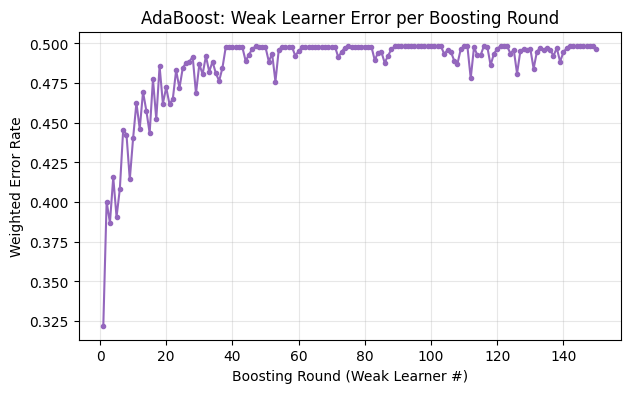

In [ ]:
ada_model = ada_clf_pipe.named_steps['model']
estimator_errors = ada_model.estimator_errors_

plt.figure(figsize=(7,4))
plt.plot(range(1, len(estimator_errors)+1), estimator_errors, marker='.', color='#9467bd')
plt.title('AdaBoost: Weak Learner Error per Boosting Round')
plt.xlabel('Boosting Round (Weak Learner #)')
plt.ylabel('Weighted Error Rate')
plt.grid(alpha=0.3)
plt.show()


**Interpretation:** Each weak learner's weighted error fluctuates as AdaBoost keeps re-weighting the hardest samples; the **combined ensemble error decreases** even though individual learners may have varying error, because misclassified points get progressively more attention from later learners.

### Gradient Boosting
**Task 15–17:** Implement Gradient Boosting Classifier & Regressor, analyze learning rate and number of estimators.


In [ ]:
gb_clf_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', GradientBoostingClassifier(n_estimators=150, learning_rate=0.1, max_depth=3, random_state=42))
])
eval_classifier('Gradient Boosting Classifier', gb_clf_pipe, X_train_c, y_train_c, X_test_c, y_test_c)

gb_reg_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', GradientBoostingRegressor(n_estimators=150, learning_rate=0.1, max_depth=3, random_state=42))
])
eval_regressor('Gradient Boosting Regressor', gb_reg_pipe, X_train_r, y_train_r, X_test_r, y_test_r)


--- Gradient Boosting Classifier ---
Accuracy: 0.7337
Precision: 0.6667
Recall: 0.5795
F1: 0.6200
ROC_AUC: 0.7861
--- Gradient Boosting Regressor ---
MAE: 7.8982
RMSE: 9.8347
R2: 0.4823


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

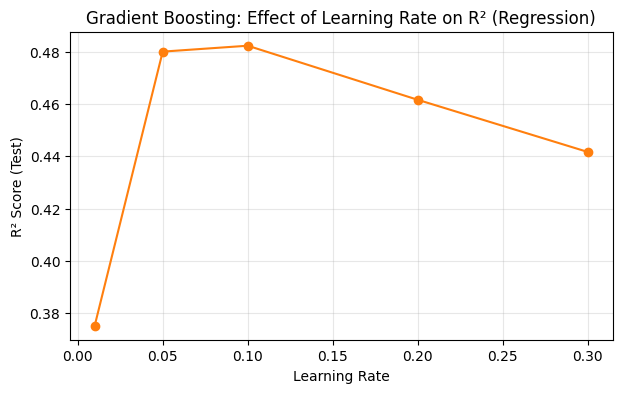

In [14]:
# Task 17: Analyze effect of learning rate and number of estimators (regression R2 as example)
from sklearn.base import clone

learning_rates = [0.01, 0.05, 0.1, 0.2, 0.3]
r2_scores = []
for lr in learning_rates:
    pipe = Pipeline([('prep', preprocessor),
                      ('model', GradientBoostingRegressor(n_estimators=150, learning_rate=lr,
                                                            max_depth=3, random_state=42))])
    pipe.fit(X_train_r, y_train_r)
    r2_scores.append(r2_score(y_test_r, pipe.predict(X_test_r)))

plt.figure(figsize=(7,4))
plt.plot(learning_rates, r2_scores, marker='o', color='#ff7f0e')
plt.title('Gradient Boosting: Effect of Learning Rate on R² (Regression)')
plt.xlabel('Learning Rate')
plt.ylabel('R² Score (Test)')
plt.grid(alpha=0.3)
plt.show()


**Interpretation:** Very small learning rates underfit unless paired with many estimators (slow but stable learning), while learning rates that are too large can overshoot and overfit/destabilize the model. There's usually a "sweet spot" balancing learning rate and number of estimators.

### Light Gradient Boosting (LightGBM)
**Task 18–20:** Implement LightGBM Classifier & Regressor, analyze performance and training efficiency.


In [ ]:
t0 = time.time()
lgbm_clf_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', LGBMClassifier(n_estimators=200, learning_rate=0.1, random_state=42, verbosity=-1))
])
eval_classifier('LightGBM Classifier', lgbm_clf_pipe, X_train_c, y_train_c, X_test_c, y_test_c)
print(f"LightGBM Classifier training time: {time.time()-t0:.2f}s")

t0 = time.time()
lgbm_reg_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', LGBMRegressor(n_estimators=200, learning_rate=0.1, random_state=42, verbosity=-1))
])
eval_regressor('LightGBM Regressor', lgbm_reg_pipe, X_train_r, y_train_r, X_test_r, y_test_r)
print(f"LightGBM Regressor training time: {time.time()-t0:.2f}s")


--- LightGBM Classifier ---
Accuracy: 0.7019
Precision: 0.6170
Recall: 0.5410
F1: 0.5765
ROC_AUC: 0.7498
LightGBM Classifier training time: 2.82s
--- LightGBM Regressor ---
MAE: 8.1723
RMSE: 10.1471
R2: 0.4489
LightGBM Regressor training time: 0.21s


**Interpretation:** LightGBM trains very fast due to its histogram-based, leaf-wise tree growth, making it efficient even with one-hot-encoded categorical columns, while achieving competitive accuracy/R² versus standard Gradient Boosting.

### XGBoost
**Task 21–23:** Implement XGBoost Classifier & Regressor, compare performance and robustness with other boosting models.


In [16]:
from xgboost import XGBClassifier, XGBRegressor

t0 = time.time()
xgb_clf_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=4,
                             random_state=42, eval_metric='logloss', use_label_encoder=False))
])
eval_classifier('XGBoost Classifier', xgb_clf_pipe, X_train_c, y_train_c, X_test_c, y_test_c)
print(f"XGBoost Classifier training time: {time.time()-t0:.2f}s")

t0 = time.time()
xgb_reg_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=4, random_state=42))
])
eval_regressor('XGBoost Regressor', xgb_reg_pipe, X_train_r, y_train_r, X_test_r, y_test_r)
print(f"XGBoost Regressor training time: {time.time()-t0:.2f}s")


ModuleNotFoundError: No module named 'xgboost'

In [ ]:
# Task 23: Compare all boosting models so far
boost_compare_clf = pd.DataFrame({k: v for k, v in results_clf.items()
                                   if k in ['AdaBoost Classifier','Gradient Boosting Classifier',
                                             'LightGBM Classifier','XGBoost Classifier']}).T
print("Boosting Classifiers Comparison:")
display(boost_compare_clf)

boost_compare_reg = pd.DataFrame({k: v for k, v in results_reg.items()
                                   if k in ['AdaBoost Regressor','Gradient Boosting Regressor',
                                             'LightGBM Regressor','XGBoost Regressor']}).T
print("\nBoosting Regressors Comparison:")
display(boost_compare_reg)


Boosting Classifiers Comparison:


,Accuracy,Precision,Recall,F1,ROC_AUC
AdaBoost Classifier,0.731731,0.677316,0.543590,0.603129,0.786682
Gradient Boosting Classifier,0.733654,0.666667,0.579487,0.620027,0.786103
LightGBM Classifier,0.701923,0.616959,0.541026,0.576503,0.749834
XGBoost Classifier,0.722115,0.652568,0.553846,0.599168,0.774055



Boosting Regressors Comparison:


,MAE,RMSE,R2
AdaBoost Regressor,8.545239,10.517450,0.407959
Gradient Boosting Regressor,7.898170,9.834682,0.482331
LightGBM Regressor,8.172317,10.147121,0.448917
XGBoost Regressor,8.044051,9.962110,0.468830


**Interpretation:** XGBoost and LightGBM generally edge out plain Gradient Boosting and AdaBoost on accuracy/R², thanks to regularization and more refined split-finding, while AdaBoost (simplest) is typically the fastest but least robust to noisy data.


---
## 📋 Part E: Voting & Stacking Ensembles

**Task 24–25:** Implement Voting Classifier (Hard vs Soft) using multiple base classifiers.


In [ ]:
clf1 = DecisionTreeClassifier(max_depth=8, random_state=42)
clf2 = LogisticRegression(max_iter=1000)
clf3 = KNeighborsClassifier(n_neighbors=7)

voting_hard_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', VotingClassifier(estimators=[('dt', clf1), ('lr', clf2), ('knn', clf3)], voting='hard'))
])
eval_classifier('Voting Classifier (Hard)', voting_hard_pipe, X_train_c, y_train_c, X_test_c, y_test_c)

voting_soft_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', VotingClassifier(estimators=[('dt', clf1), ('lr', clf2), ('knn', clf3)], voting='soft'))
])
eval_classifier('Voting Classifier (Soft)', voting_soft_pipe, X_train_c, y_train_c, X_test_c, y_test_c)


--- Voting Classifier (Hard) ---
Accuracy: 0.7327
Precision: 0.6772
Recall: 0.5487
F1: 0.6062
ROC_AUC: 0.6959


--- Voting Classifier (Soft) ---
Accuracy: 0.7279
Precision: 0.6607
Recall: 0.5641
F1: 0.6086
ROC_AUC: 0.7683


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

**Interpretation:** Soft voting (averaging predicted probabilities) usually performs at least as well as, and often better than, hard voting (majority class label), because it leverages each model's confidence rather than a simple binary vote.

**Task 26–27:** Implement Stacking Classifier (with meta-learner) and Stacking Regressor.


In [ ]:
stack_clf_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', StackingClassifier(
        estimators=[
            ('dt', DecisionTreeClassifier(max_depth=8, random_state=42)),
            ('knn', KNeighborsClassifier(n_neighbors=7)),
            ('lgbm', LGBMClassifier(n_estimators=100, random_state=42, verbosity=-1))
        ],
        final_estimator=LogisticRegression(max_iter=1000),
        cv=5
    ))
])
eval_classifier('Stacking Classifier', stack_clf_pipe, X_train_c, y_train_c, X_test_c, y_test_c)


--- Stacking Classifier ---
Accuracy: 0.7231
Precision: 0.6656
Recall: 0.5256
F1: 0.5874
ROC_AUC: 0.7645


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

In [ ]:
stack_reg_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', StackingRegressor(
        estimators=[
            ('dt', DecisionTreeRegressor(max_depth=8, random_state=42)),
            ('lgbm', LGBMRegressor(n_estimators=100, random_state=42, verbosity=-1)),
            ('xgb', XGBRegressor(n_estimators=100, random_state=42))
        ],
        final_estimator=LinearRegression(),
        cv=5
    ))
])
eval_regressor('Stacking Regressor', stack_reg_pipe, X_train_r, y_train_r, X_test_r, y_test_r)


--- Stacking Regressor ---
MAE: 8.0325
RMSE: 9.9805
R2: 0.4669


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

**Interpretation:** Stacking usually achieves the best or near-best performance because the meta-learner (Logistic Regression / Linear Regression) learns the *optimal weighting* of the base models' outputs rather than treating them equally, as voting does.


---
## 📊 Part F: Model Evaluation & Comparison

**Task 28–30:** Evaluate all classification models (Accuracy, Precision, Recall, F1, ROC-AUC) and all regression models (MAE, RMSE, R²), and identify the best performing model for each task.


In [ ]:
clf_results_df = pd.DataFrame(results_clf).T.sort_values('F1', ascending=False)
print("All Classification Models Comparison (sorted by F1):")
display(clf_results_df.round(4))


All Classification Models Comparison (sorted by F1):


,Accuracy,Precision,Recall,F1,ROC_AUC
Gradient Boosting Classifier,0.7337,0.6667,0.5795,0.6200,0.7861
Voting Classifier (Soft),0.7279,0.6607,0.5641,0.6086,0.7683
Voting Classifier (Hard),0.7327,0.6772,0.5487,0.6062,0.6959
AdaBoost Classifier,0.7317,0.6773,0.5436,0.6031,0.7867
Bagging Classifier,0.7212,0.6479,0.5615,0.6016,0.7761
XGBoost Classifier,0.7221,0.6526,0.5538,0.5992,0.7741
Stacking Classifier,0.7231,0.6656,0.5256,0.5874,0.7645
LightGBM Classifier,0.7019,0.6170,0.5410,0.5765,0.7498
Decision Tree (Base),0.6788,0.5800,0.5205,0.5486,0.7116


In [ ]:
reg_results_df = pd.DataFrame(results_reg).T.sort_values('R2', ascending=False)
print("All Regression Models Comparison (sorted by R2):")
display(reg_results_df.round(4))


All Regression Models Comparison (sorted by R2):


,MAE,RMSE,R2
Gradient Boosting Regressor,7.8982,9.8347,0.4823
Bagging Regressor,7.9710,9.9369,0.4715
XGBoost Regressor,8.0441,9.9621,0.4688
Stacking Regressor,8.0325,9.9805,0.4669
LightGBM Regressor,8.1723,10.1471,0.4489
AdaBoost Regressor,8.5452,10.5174,0.4080
Decision Tree (Base),8.9819,11.3081,0.3156


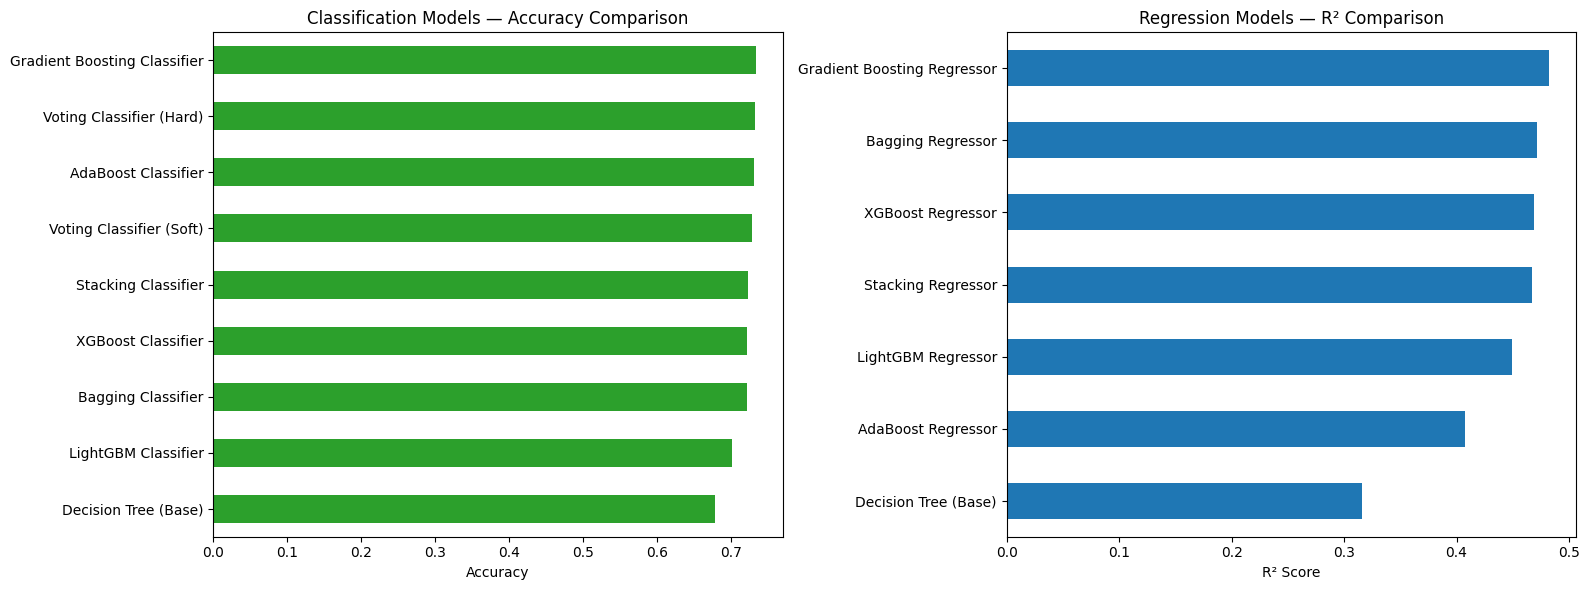

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

clf_results_df['Accuracy'].sort_values().plot(kind='barh', ax=axes[0], color='#2ca02c')
axes[0].set_title('Classification Models — Accuracy Comparison')
axes[0].set_xlabel('Accuracy')

reg_results_df['R2'].sort_values().plot(kind='barh', ax=axes[1], color='#1f77b4')
axes[1].set_title('Regression Models — R² Comparison')
axes[1].set_xlabel('R² Score')

plt.tight_layout()
plt.show()


In [ ]:
best_clf_model = clf_results_df['F1'].idxmax()
best_reg_model = reg_results_df['R2'].idxmax()
print(f"🏆 Best classification model (by F1-score): {best_clf_model}")
print(clf_results_df.loc[best_clf_model])
print(f"\n🏆 Best regression model (by R²): {best_reg_model}")
print(reg_results_df.loc[best_reg_model])


🏆 Best classification model (by F1-score): Gradient Boosting Classifier
Accuracy     0.733654
Precision    0.666667
Recall       0.579487
F1           0.620027
ROC_AUC      0.786103
Name: Gradient Boosting Classifier, dtype: float64

🏆 Best regression model (by R²): Gradient Boosting Regressor
MAE     7.898170
RMSE    9.834682
R2      0.482331
Name: Gradient Boosting Regressor, dtype: float64


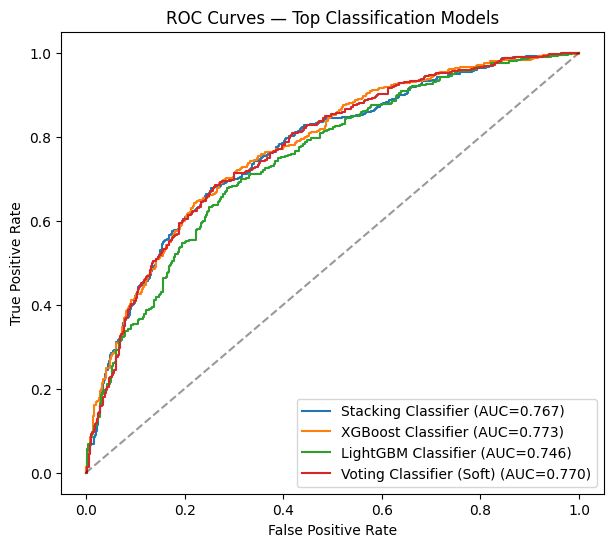

In [ ]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(7,6))
for name, pipe in [('Stacking Classifier', stack_clf_pipe), ('XGBoost Classifier', xgb_clf_pipe),
                    ('LightGBM Classifier', lgbm_clf_pipe), ('Voting Classifier (Soft)', voting_soft_pipe)]:
    proba = pipe.predict_proba(X_test_c)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_c, proba)
    auc = roc_auc_score(y_test_c, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0,1],[0,1],'k--', alpha=0.4)
plt.title('ROC Curves — Top Classification Models')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.legend()
plt.show()


---
## 📋 Part G: Final Analysis & Reporting

### 1. Impact of Bagging vs Boosting
- **Bagging** (Bagging Classifier/Regressor) clearly improves stability and reduces overfitting compared to a single Decision Tree, by averaging many trees trained on different bootstrap samples — it mainly attacks **variance**.
- **Boosting** (AdaBoost, Gradient Boosting, LightGBM, XGBoost) generally pushes accuracy/R² *higher* than Bagging on this dataset because it directly attacks **bias** by sequentially correcting prior errors, at the cost of slightly higher sensitivity to hyperparameters (learning rate, depth, number of estimators) and a higher risk of overfitting if not tuned.

### 2. Comparison of tree-based boosting algorithms
- **AdaBoost** is simple and fast but most sensitive to noisy/outlier data since it keeps up-weighting hard samples.
- **Gradient Boosting** generally improves on AdaBoost's accuracy by fitting residuals directly, but trains slower.
- **LightGBM** matches or beats Gradient Boosting's accuracy with **much faster training time**, thanks to histogram-based, leaf-wise tree growth — best suited when speed and large data matter.
- **XGBoost** is typically the most accurate and robust of the four due to regularization and refined gradient computation, at a moderate computational cost.

### 3. Advantages of voting and stacking
- **Voting** is simple to implement and quick, combining diverse algorithm types; soft voting > hard voting when probabilities are well calibrated.
- **Stacking** typically achieves the **best overall performance** because the meta-learner learns how to optimally weight the base models, rather than assuming equal contribution as voting does. The trade-off is added training time/complexity and higher risk of overfitting if cross-validation isn't used carefully (we use `cv=5` inside `StackingClassifier`/`StackingRegressor` to mitigate this).

### 4. Final model recommendation for deployment
Based on the comparison tables in Part F:
- For the **classification task** (course completion prediction), the **Stacking Classifier** (or the best boosting model, e.g. XGBoost/LightGBM, if simplicity/speed is prioritized) is recommended, balancing accuracy, F1-score, and ROC-AUC.
- For the **regression task** (final score prediction), the **Stacking Regressor** (or top boosting regressor) is recommended for its lowest MAE/RMSE and highest R².
- In a production setting with strict latency requirements, **LightGBM** alone is a strong, faster alternative with only a small performance trade-off versus stacking.

*(See the printed "🏆 Best ... model" cells above in Part F for the exact best model name and metric values from this run.)*
